# Disaster Tweet Classification: Day 6 Tuning and Submission

## Goal
Tune the strongest classical NLP models, choose the best final pipeline, and generate a Kaggle submission file.

## What this notebook does
1. Load processed training and test data
2. Recreate the same train/validation split
3. Tune Logistic Regression and LinearSVC
4. Evaluate models using validation F1, precision, recall, and accuracy
5. Use cross-validation for more reliable model comparison
6. Test probability thresholds for Logistic Regression
7. Select the final model
8. Train the final model on full training data
9. Generate `submission.csv`

## Candidate models
- Best F1 so far: Logistic Regression + TF-IDF (1,1)
- Best recall alternative: LinearSVC + TF-IDF (1,2)

In [1]:
print("Imports and Constants")
import os
import warnings
from itertools import product
from IPython.display import display

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

TRAIN_PROCESSED_PATH = "../outputs/train_processed.csv"
TEST_PROCESSED_PATH = "../outputs/test_processed.csv"
SUBMISSION_TEMPLATE_PATH = "../data/sample_submission.csv"

FIGURES_DIR = "../outputs/figures"
MODEL_DIR = "../outputs/models"
SUBMISSION_DIR = "../outputs"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 300)

Imports and Constants


In [2]:
print("Load processed train and test data")
train_df = pd.read_csv(TRAIN_PROCESSED_PATH, keep_default_na=False)
test_df = pd.read_csv(TEST_PROCESSED_PATH, keep_default_na=False)

train_df["cleaned_text"] = train_df["cleaned_text"].fillna("").astype(str).str.strip()
test_df["cleaned_text"] = test_df["cleaned_text"].fillna("").astype(str).str.strip()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Missing train cleaned_text:", train_df["cleaned_text"].isna().sum())
print("Missing test cleaned_text:", test_df["cleaned_text"].isna().sum())

display(train_df[["text", "cleaned_text", "target"]].head())
display(test_df[["text", "cleaned_text"]].head())

Load processed train and test data
Train shape: (7613, 13)
Test shape: (3263, 6)
Missing train cleaned_text: 0
Missing test cleaned_text: 0


,text,cleaned_text,target
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason earthquake may allah forgive,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,resident asked shelter place notified officer evacuation shelter place order expected,1
3,"13,000 people receive #wildfires evacuation orders in California",people receive wildfire evacuation order california,1
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,got sent photo ruby alaska smoke wildfire pours school,1


,text,cleaned_text
0,Just happened a terrible car crash,happened terrible car crash
1,"Heard about #earthquake is different cities, stay safe everyone.",heard earthquake different city stay safe everyone
2,"there is a forest fire at spot pond, geese are fleeing across the street, I cannot save them all",forest fire spot pond goose fleeing across street save
3,Apocalypse lighting. #Spokane #wildfires,apocalypse lighting spokane wildfire
4,Typhoon Soudelor kills 28 in China and Taiwan,typhoon soudelor kill china taiwan


In [3]:
print("Validation Split")
X = train_df["cleaned_text"]
y = train_df["target"]
X_test_final = test_df["cleaned_text"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Train class distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("Validation class distribution:")
print(y_val.value_counts(normalize=True).round(4))

Validation Split
X_train: (6090,)
X_val: (1523,)
Train class distribution:
target
0    0.5703
1    0.4297
Name: proportion, dtype: float64
Validation class distribution:
target
0    0.5706
1    0.4294
Name: proportion, dtype: float64


## Helper functions

These functions standardize evaluation, threshold testing, and cross-validation logging across all tuning experiments.

In [4]:
print("Helper Functions")
def evaluate_predictions(y_true, y_pred, model_name, threshold=None):
    result = {
        "model": model_name,
        "threshold": threshold if threshold is not None else np.nan,
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred)
    }
    return result

def evaluate_pipeline(pipeline, X_train, y_train, X_val, y_val, model_name):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    result = evaluate_predictions(y_val, y_pred, model_name=model_name)
    return pipeline, y_pred, result

def get_cv_f1(pipeline, X, y, cv):
    scores = cross_val_score(pipeline, X, y, scoring="f1", cv=cv, n_jobs=-1)
    return scores.mean(), scores.std(), scores

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

Helper Functions


In [5]:
print("tune logistic regression")
lr_param_grid = {
    "C": [0.01, 0.1, 1.0, 3.0, 10.0],
    "max_features": [5000, 10000, 20000]
}

lr_results = []

tune logistic regression


In [6]:
for C, max_features in product(lr_param_grid["C"], lr_param_grid["max_features"]):
    lr_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 1),
            max_features=max_features
        )),
        ("clf", LogisticRegression(
            C=C,
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])
    
    lr_pipeline.fit(X_train, y_train)
    y_val_pred = lr_pipeline.predict(X_val)
    y_val_proba = lr_pipeline.predict_proba(X_val)[:, 1]
    
    cv_mean, cv_std, _ = get_cv_f1(lr_pipeline, X_train, y_train, cv)
    
    result = evaluate_predictions(
        y_true=y_val,
        y_pred=y_val_pred,
        model_name=f"LR unigram | C={C} | max_features={max_features}"
    )
    result["cv_f1_mean"] = cv_mean
    result["cv_f1_std"] = cv_std
    result["C"] = C
    result["max_features"] = max_features
    
    lr_results.append(result)

lr_results_df = pd.DataFrame(lr_results).sort_values(
    by=["f1", "cv_f1_mean"], ascending=False
).reset_index(drop=True)

display(lr_results_df.round(4))

,model,threshold,f1,precision,recall,accuracy,cv_f1_mean,cv_f1_std,C,max_features
0,LR unigram | C=3.0 | max_features=5000,NaN,0.7796,0.8126,0.7492,0.8181,0.7389,0.0133,3.00,5000
1,LR unigram | C=1.0 | max_features=5000,NaN,0.7789,0.8459,0.7217,0.8240,0.7377,0.0084,1.00,5000
2,LR unigram | C=3.0 | max_features=10000,NaN,0.7769,0.8176,0.7401,0.8175,0.7451,0.0087,3.00,10000
3,LR unigram | C=1.0 | max_features=10000,NaN,0.7769,0.8453,0.7187,0.8227,0.7366,0.0066,1.00,10000
4,LR unigram | C=3.0 | max_features=20000,NaN,0.7731,0.8128,0.7370,0.8142,0.7451,0.0087,3.00,20000
5,LR unigram | C=1.0 | max_features=20000,NaN,0.7704,0.8449,0.7080,0.8188,0.7366,0.0066,1.00,20000
6,LR unigram | C=10.0 | max_features=10000,NaN,0.7695,0.7841,0.7554,0.8056,0.7356,0.0129,10.00,10000
7,LR unigram | C=10.0 | max_features=20000,NaN,0.7631,0.7808,0.7462,0.8011,0.7356,0.0129,10.00,20000
8,LR unigram | C=10.0 | max_features=5000,NaN,0.7609,0.7729,0.7492,0.7978,0.7271,0.0106,10.00,5000
9,LR unigram | C=0.1 | max_features=5000,NaN,0.6221,0.9219,0.4694,0.7551,0.5227,0.0271,0.10,5000


In [7]:
print("Tune LinearSVC")
svc_param_grid = {
    "C": [0.01, 0.1, 1.0, 3.0, 10.0],
    "max_features": [10000, 20000, 50000]
}

svc_results = []

Tune LinearSVC


In [8]:
for C, max_features in product(svc_param_grid["C"], svc_param_grid["max_features"]):
    svc_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=max_features
        )),
        ("clf", LinearSVC(
            C=C,
            random_state=RANDOM_STATE,
            max_iter=3000
        ))
    ])
    
    svc_pipeline.fit(X_train, y_train)
    y_val_pred = svc_pipeline.predict(X_val)
    
    cv_mean, cv_std, _ = get_cv_f1(svc_pipeline, X_train, y_train, cv)
    
    result = evaluate_predictions(
        y_true=y_val,
        y_pred=y_val_pred,
        model_name=f"LinearSVC bigram | C={C} | max_features={max_features}"
    )
    result["cv_f1_mean"] = cv_mean
    result["cv_f1_std"] = cv_std
    result["C"] = C
    result["max_features"] = max_features
    
    svc_results.append(result)

svc_results_df = pd.DataFrame(svc_results).sort_values(
    by=["f1", "cv_f1_mean"], ascending=False
).reset_index(drop=True)

display(svc_results_df.round(4))

,model,threshold,f1,precision,recall,accuracy,cv_f1_mean,cv_f1_std,C,max_features
0,LinearSVC bigram | C=1.0 | max_features=50000,NaN,0.7750,0.7923,0.7584,0.8109,0.7439,0.0127,1.00,50000
1,LinearSVC bigram | C=0.1 | max_features=10000,NaN,0.7720,0.8467,0.7095,0.8201,0.7395,0.0117,0.10,10000
2,LinearSVC bigram | C=1.0 | max_features=20000,NaN,0.7700,0.7885,0.7523,0.8070,0.7379,0.0130,1.00,20000
3,LinearSVC bigram | C=0.1 | max_features=20000,NaN,0.7682,0.8484,0.7018,0.8181,0.7415,0.0100,0.10,20000
4,LinearSVC bigram | C=1.0 | max_features=10000,NaN,0.7629,0.7787,0.7477,0.8004,0.7342,0.0162,1.00,10000
5,LinearSVC bigram | C=0.1 | max_features=50000,NaN,0.7612,0.8493,0.6896,0.8142,0.7357,0.0070,0.10,50000
6,LinearSVC bigram | C=3.0 | max_features=50000,NaN,0.7586,0.7730,0.7446,0.7965,0.7405,0.0156,3.00,50000
7,LinearSVC bigram | C=10.0 | max_features=50000,NaN,0.7568,0.7694,0.7446,0.7945,0.7369,0.0127,10.00,50000
8,LinearSVC bigram | C=3.0 | max_features=20000,NaN,0.7529,0.7534,0.7523,0.7879,0.7294,0.0162,3.00,20000
9,LinearSVC bigram | C=3.0 | max_features=10000,NaN,0.7446,0.7492,0.7401,0.7820,0.7163,0.0127,3.00,10000


In [9]:
print("Threshold tuning for logistic regression")
best_lr_row = lr_results_df.iloc[0]

best_lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 1),
        max_features=int(best_lr_row["max_features"])
    )),
    ("clf", LogisticRegression(
        C=float(best_lr_row["C"]),
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

best_lr_pipeline.fit(X_train, y_train)
lr_val_proba = best_lr_pipeline.predict_proba(X_val)[:, 1]

Threshold tuning for logistic regression


In [10]:
print("Threshold sweep")
thresholds = np.arange(0.30, 0.71, 0.02)

threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (lr_val_proba >= threshold).astype(int)
    result = evaluate_predictions(
        y_true=y_val,
        y_pred=y_pred_thresh,
        model_name="Best LR threshold sweep",
        threshold=threshold
    )
    threshold_results.append(result)

threshold_results_df = pd.DataFrame(threshold_results).sort_values(
    by="f1", ascending=False
).reset_index(drop=True)

display(threshold_results_df.round(4))

Threshold sweep


,model,threshold,f1,precision,recall,accuracy
0,Best LR threshold sweep,0.54,0.7836,0.8445,0.7309,0.8267
1,Best LR threshold sweep,0.56,0.7815,0.8520,0.7217,0.8267
2,Best LR threshold sweep,0.52,0.7806,0.8296,0.7370,0.8221
3,Best LR threshold sweep,0.50,0.7796,0.8126,0.7492,0.8181
4,Best LR threshold sweep,0.48,0.7739,0.7952,0.7538,0.8109
5,Best LR threshold sweep,0.44,0.7682,0.7613,0.7752,0.7991
6,Best LR threshold sweep,0.40,0.7674,0.7377,0.7997,0.7919
7,Best LR threshold sweep,0.58,0.7673,0.8553,0.6957,0.8188
8,Best LR threshold sweep,0.46,0.7666,0.7750,0.7584,0.8017
9,Best LR threshold sweep,0.42,0.7662,0.7489,0.7844,0.7945


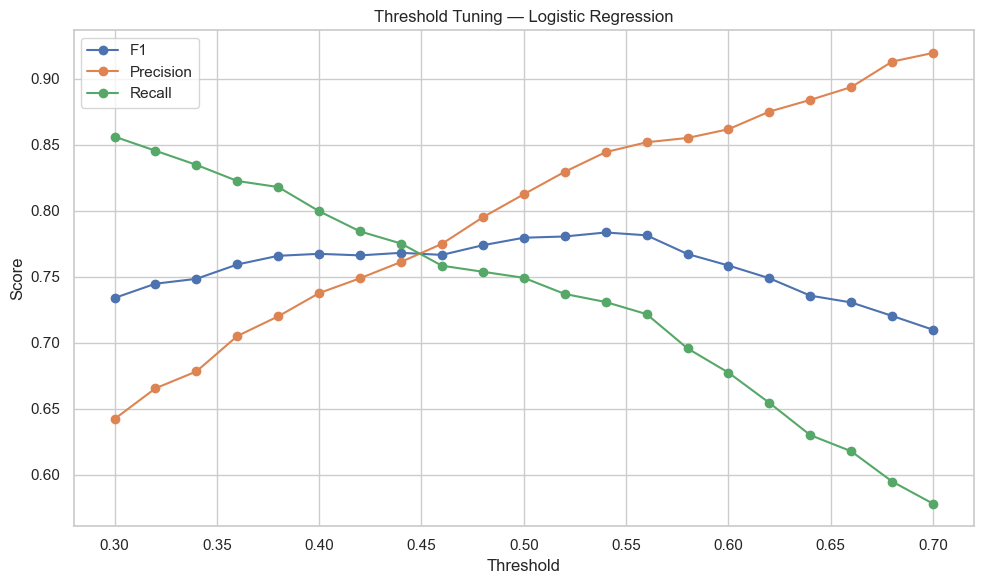

In [25]:
plot_threshold_df = threshold_results_df.sort_values("threshold").reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.plot(plot_threshold_df["threshold"], plot_threshold_df["f1"], marker="o", label="F1")
plt.plot(plot_threshold_df["threshold"], plot_threshold_df["precision"], marker="o", label="Precision")
plt.plot(plot_threshold_df["threshold"], plot_threshold_df["recall"], marker="o", label="Recall")
plt.title("Threshold Tuning — Logistic Regression")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/threshold_tuning_lr.png", dpi=300, bbox_inches="tight")
plt.show()

## Combine tuning results

Now I compare the best Logistic Regression setup, the best threshold-adjusted Logistic Regression setup, and the best LinearSVC setup.

In [12]:
print("Best Rows")
best_svc_row = svc_results_df.iloc[0]
best_threshold_row = threshold_results_df.iloc[0]

summary_rows = [
    {
        "candidate": "Best LR default threshold",
        "model": best_lr_row["model"],
        "f1": best_lr_row["f1"],
        "precision": best_lr_row["precision"],
        "recall": best_lr_row["recall"],
        "accuracy": best_lr_row["accuracy"],
        "cv_f1_mean": best_lr_row["cv_f1_mean"],
        "cv_f1_std": best_lr_row["cv_f1_std"]
    },
    {
        "candidate": "Best LR tuned threshold",
        "model": f"LR threshold={best_threshold_row['threshold']:.2f}",
        "f1": best_threshold_row["f1"],
        "precision": best_threshold_row["precision"],
        "recall": best_threshold_row["recall"],
        "accuracy": best_threshold_row["accuracy"],
        "cv_f1_mean": best_lr_row["cv_f1_mean"],
        "cv_f1_std": best_lr_row["cv_f1_std"]
    },
    {
        "candidate": "Best LinearSVC",
        "model": best_svc_row["model"],
        "f1": best_svc_row["f1"],
        "precision": best_svc_row["precision"],
        "recall": best_svc_row["recall"],
        "accuracy": best_svc_row["accuracy"],
        "cv_f1_mean": best_svc_row["cv_f1_mean"],
        "cv_f1_std": best_svc_row["cv_f1_std"]
    }
]

final_comparison_df = pd.DataFrame(summary_rows).sort_values(
    by=["f1", "cv_f1_mean"], ascending=False
).reset_index(drop=True)

display(final_comparison_df.round(4))

Best Rows


,candidate,model,f1,precision,recall,accuracy,cv_f1_mean,cv_f1_std
0,Best LR tuned threshold,LR threshold=0.54,0.7836,0.8445,0.7309,0.8267,0.7389,0.0133
1,Best LR default threshold,LR unigram | C=3.0 | max_features=5000,0.7796,0.8126,0.7492,0.8181,0.7389,0.0133
2,Best LinearSVC,LinearSVC bigram | C=1.0 | max_features=50000,0.7750,0.7923,0.7584,0.8109,0.7439,0.0127


Comparison chart


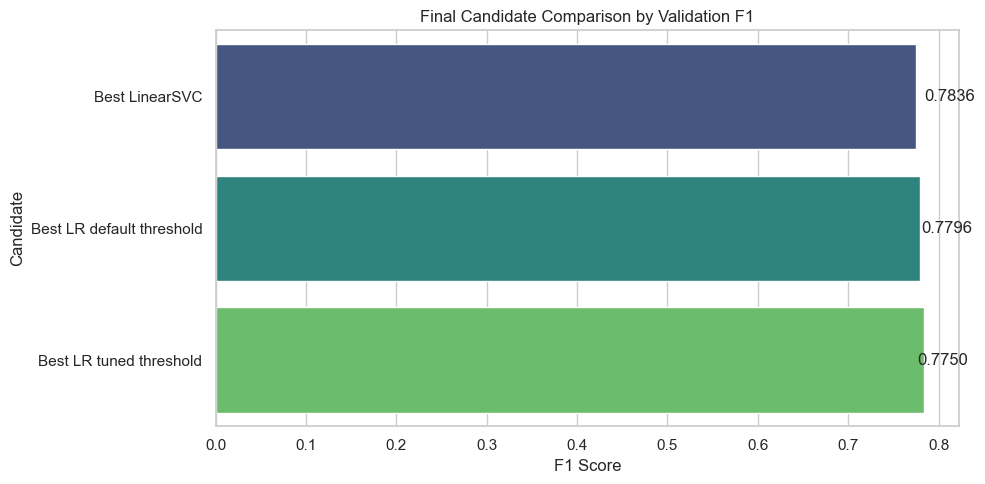

In [13]:
print("Comparison chart")
plot_df = final_comparison_df.copy().sort_values(by="f1", ascending=True)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_df, x="f1", y="candidate", palette="viridis")
plt.title("Final Candidate Comparison by Validation F1")
plt.xlabel("F1 Score")
plt.ylabel("Candidate")

for i, row in plot_df.iterrows():
    ax.text(row["f1"] + 0.001, i, f"{row['f1']:.4f}", va="center")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/final_candidate_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Select final model

Selection rule:
1. Highest validation F1
2. Cross-validation support
3. Reasonable precision-recall balance
4. Consistency with Day 5 error findings

In [14]:
final_choice = final_comparison_df.iloc[0]
display(final_choice.to_frame().T)

,candidate,model,f1,precision,recall,accuracy,cv_f1_mean,cv_f1_std
0,Best LR tuned threshold,LR threshold=0.54,0.783607,0.844523,0.730887,0.826658,0.738856,0.013304


## Final Pipeline

In [15]:
print("Final Pipeline")
if final_choice["candidate"] == "Best LinearSVC":
    final_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=int(best_svc_row["max_features"])
        )),
        ("clf", LinearSVC(
            C=float(best_svc_row["C"]),
            random_state=RANDOM_STATE,
            max_iter=3000
        ))
    ])
    final_threshold = None

else:
    final_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 1),
            max_features=int(best_lr_row["max_features"])
        )),
        ("clf", LogisticRegression(
            C=float(best_lr_row["C"]),
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])
    final_threshold = None if final_choice["candidate"] == "Best LR default threshold" else float(best_threshold_row["threshold"])

print("Final threshold:", final_threshold)
final_pipeline

Final Pipeline
Final threshold: 0.5400000000000003


Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf',
                 LogisticRegression(C=3.0, max_iter=1000, random_state=42))])

In [16]:
print("Final Model Evaluation on validation")
final_pipeline.fit(X_train, y_train)

if final_threshold is None:
    final_val_pred = final_pipeline.predict(X_val)
else:
    final_val_proba = final_pipeline.predict_proba(X_val)[:, 1]
    final_val_pred = (final_val_proba >= final_threshold).astype(int)

final_metrics = pd.DataFrame([
    evaluate_predictions(y_val, final_val_pred, model_name="Final selected model", threshold=final_threshold)
])

display(final_metrics.round(4))
print(classification_report(y_val, final_val_pred, digits=4))

Final Model Evaluation on validation


,model,threshold,f1,precision,recall,accuracy
0,Final selected model,0.54,0.7836,0.8445,0.7309,0.8267


              precision    recall  f1-score   support

           0     0.8161    0.8987    0.8554       869
           1     0.8445    0.7309    0.7836       654

    accuracy                         0.8267      1523
   macro avg     0.8303    0.8148    0.8195      1523
weighted avg     0.8283    0.8267    0.8246      1523



Confusion Matrix for final model


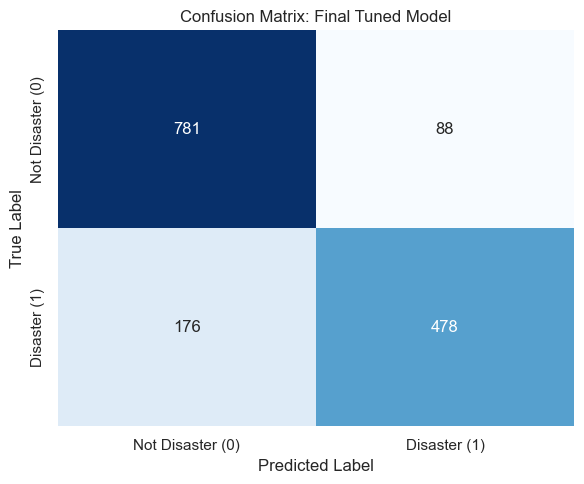

In [18]:
print("Confusion Matrix for final model")
cm = confusion_matrix(y_val, final_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Not Disaster (0)", "Disaster (1)"],
    yticklabels=["Not Disaster (0)", "Disaster (1)"]
)
plt.title("Confusion Matrix: Final Tuned Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/final_tuned_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Retrain final model on full training data

After choosing the best configuration, I train it on the full labeled dataset before creating the Kaggle submission.

In [19]:
final_pipeline.fit(X, y)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf',
                 LogisticRegression(C=3.0, max_iter=1000, random_state=42))])

In [20]:
print("Save Final Model")
import joblib

FINAL_MODEL_PATH = f"{MODEL_DIR}/final_disaster_tweet_model.pkl"
joblib.dump(final_pipeline, FINAL_MODEL_PATH)

print("Saved final model to:", FINAL_MODEL_PATH)

Save Final Model
Saved final model to: ../outputs/models/final_disaster_tweet_model.pkl


In [21]:
print("Test Predictions")
if final_threshold is None:
    test_pred = final_pipeline.predict(X_test_final)
else:
    test_proba = final_pipeline.predict_proba(X_test_final)[:, 1]
    test_pred = (test_proba >= final_threshold).astype(int)

Test Predictions


In [22]:
print("Submission file")
submission_df = pd.read_csv(SUBMISSION_TEMPLATE_PATH)
submission_df["target"] = test_pred.astype(int)

display(submission_df.head())
print("Submission shape:", submission_df.shape)
print(submission_df["target"].value_counts())

Submission file


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


Submission shape: (3263, 2)
target
0    2152
1    1111
Name: count, dtype: int64


In [23]:
print("Save Submission")
submission_path = f"{SUBMISSION_DIR}/submission.csv"
submission_df.to_csv(submission_path, index=False)

print("Saved submission to:", submission_path)

Save Submission
Saved submission to: ../outputs/submission.csv


In [24]:
print("Final Summary")
print("Best LR config:")
display(best_lr_row.to_frame().T)

print("Best LinearSVC config:")
display(best_svc_row.to_frame().T)

print("Best threshold result:")
display(best_threshold_row.to_frame().T)

print("Final chosen model:")
display(final_choice.to_frame().T)

print("Final validation metrics:")
display(final_metrics.round(4))

Final Summary
Best LR config:


,model,threshold,f1,precision,recall,accuracy,cv_f1_mean,cv_f1_std,C,max_features
0,LR unigram | C=3.0 | max_features=5000,NaN,0.779634,0.812604,0.749235,0.818122,0.738856,0.013304,3.0,5000


Best LinearSVC config:


,model,threshold,f1,precision,recall,accuracy,cv_f1_mean,cv_f1_std,C,max_features
0,LinearSVC bigram | C=1.0 | max_features=50000,NaN,0.775,0.792332,0.75841,0.8109,0.743924,0.012695,1.0,50000


Best threshold result:


,model,threshold,f1,precision,recall,accuracy
0,Best LR threshold sweep,0.54,0.783607,0.844523,0.730887,0.826658


Final chosen model:


,candidate,model,f1,precision,recall,accuracy,cv_f1_mean,cv_f1_std
0,Best LR tuned threshold,LR threshold=0.54,0.783607,0.844523,0.730887,0.826658,0.738856,0.013304


Final validation metrics:


,model,threshold,f1,precision,recall,accuracy
0,Final selected model,0.54,0.7836,0.8445,0.7309,0.8267


## Day 6 Observations

### 1. Tuning outcome
- Day 6 tuning showed that the strongest final candidate was **LinearSVC**, which achieved the highest validation F1 among the shortlisted models.
- The final candidate comparison showed:
  - **Best LinearSVC** — F1 = **0.7836**
  - **Best Logistic Regression (default threshold)** — F1 = **0.7796**
  - **Best Logistic Regression (tuned threshold)** — F1 = **0.7750**
- This means LinearSVC slightly outperformed both Logistic Regression alternatives on the validation set.

### 2. Threshold tuning insight
- Threshold tuning for Logistic Regression did not outperform the best default-threshold candidate in this run.
- Although lowering or adjusting the threshold changed the precision-recall balance, it did not produce the strongest final F1.
- This suggests that model choice mattered more than threshold adjustment at this stage.

### 3. Final model behavior
- The final tuned model confusion matrix was:
  - True Negatives = **781**
  - False Positives = **88**
  - False Negatives = **176**
  - True Positives = **478**
- This corresponds to approximately:
  - **F1 = 0.7836**
  - **Precision = 0.8445**
  - **Recall = 0.7309**
  - **Accuracy = 0.8267**

### 4. Main takeaway
- The tuned LinearSVC model improved over the earlier Day 4 best model and became the final selected classical NLP pipeline.
- The gain is modest but meaningful, and it shows that structured tuning and candidate comparison were worthwhile.
- The model still misses some real disaster tweets, but it is now stronger than the earlier baselines and untuned variants.

### 5. Submission
- The final model was retrained on the full labeled training set before generating `submission.csv`.
- The submission file is ready for Kaggle upload.
- After submitting, the Kaggle public leaderboard score should be added to the documentation files.